Train accuracy: 0.9938
Validation accuracy: 0.9752


Computing conditional permutation importance: 100%|██████████| 140/140 [11:30<00:00,  4.93s/feature]


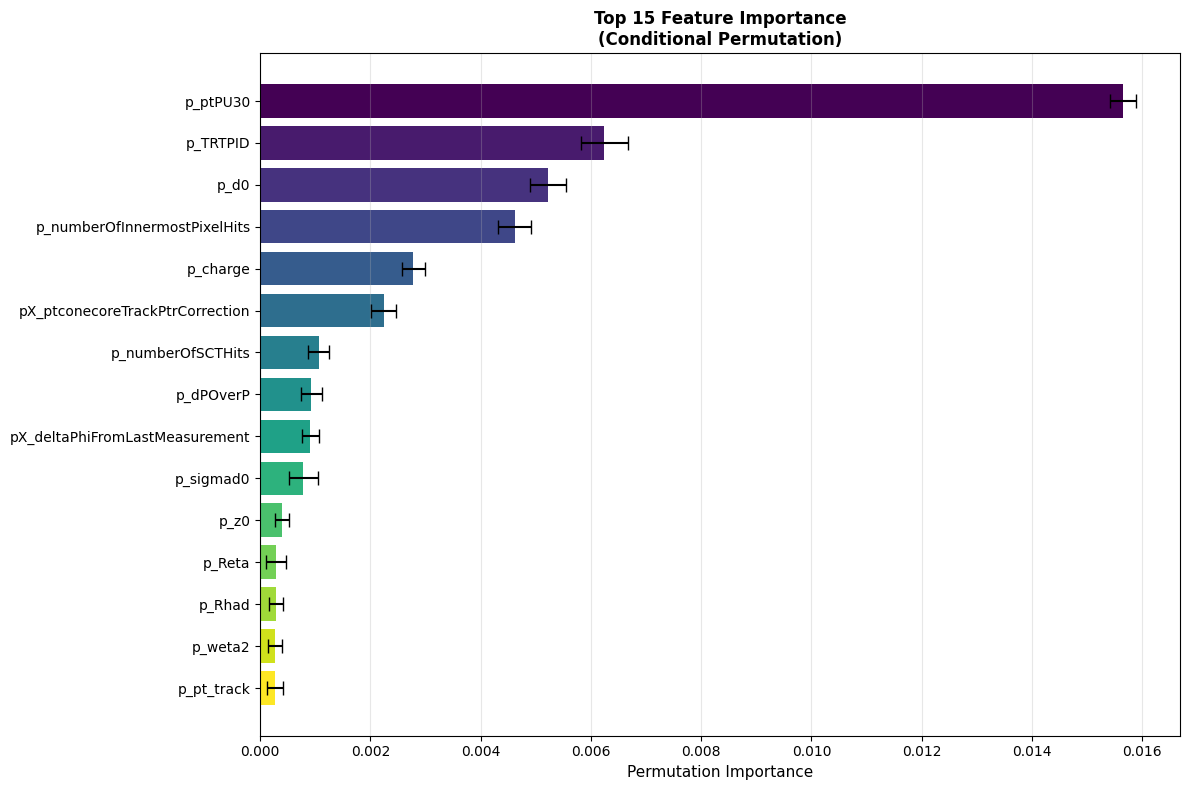

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier, XGBRegressor
from tqdm import tqdm

# Load data
class_train_data = pd.read_csv('../Data/AppML_InitialProject_train.csv')
class_test_data = pd.read_csv('../Data/AppML_InitialProject_test_classification.csv')

# Prepare features and target
target = class_train_data['p_Truth_isElectron']
variables = class_train_data.drop(columns=['p_Truth_isElectron', 'p_Truth_Energy'])

# Split into train/validation for calculating importance on unseen data
X_train, X_val, y_train, y_val = train_test_split(
    variables, target, test_size=0.2, random_state=42, stratify=target
)

# Train XGBoost model
model = XGBClassifier(
    n_estimators = 700,
    max_depth = 7,
    learning_rate = 0.04,
    subsample = 0.6,
    colsample_bytree = 0.85,
    gamma = 2.4,
    min_child_weight = 7,
    eval_metric = 'logloss',
    random_state = 42,
    n_jobs = -1
)

model.fit(X_train, y_train)

# Evaluate on validation set
train_score = model.score(X_train, y_train)
val_score = model.score(X_val, y_val)
print(f'Train accuracy: {train_score:.4f}')
print(f'Validation accuracy: {val_score:.4f}')

# Conditional permutation importance (using XGBoost regressors to model feature|others)
# Approximates conditional draws by predicting E[feature|others] on VAL and adding


def conditional_permutation_importance(model, X_train, X_val, y_val, features, n_repeats=20, rng_seed=42):
    rng = np.random.default_rng(rng_seed)
    baseline = model.score(X_val, y_val)
    records = []
    for feature in tqdm(features, desc='Computing conditional permutation importance', unit='feature'):
        # Get other features
        other_cols = [c for c in X_train.columns if c != feature]

        # Fit XGBoost regressor to predict this feature from the others (TRAIN)
        reg = XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.05, random_state=42, n_jobs=-1)
        reg.fit(X_train[other_cols], X_train[feature])

        # Get residuals on TRAIN
        preds_train = reg.predict(X_train[other_cols])
        residuals = (X_train[feature] - preds_train).to_numpy()
        
        drops = []
        
        # Permute feature by sampling from conditional distribution and measure drop in performance
        for _ in range(n_repeats):
            preds_val = reg.predict(X_val[other_cols])
            sampled_resid = rng.choice(residuals, size=len(preds_val), replace=True)
            Xc = X_val.copy()
            Xc[feature] = preds_val + sampled_resid
            perm_score = model.score(Xc, y_val)
            drops.append(baseline - perm_score)
        records.append((feature, float(np.mean(drops)), float(np.std(drops))))
    imp_df = pd.DataFrame(records, columns=['feature', 'importance', 'std']).sort_values('importance', ascending=False)
    return imp_df

# Run conditional permutation importance
importance_df = conditional_permutation_importance(model, X_train, X_val, y_val, n_repeats=20, rng_seed=42)

# Bar plot
top_n = 15
top_features = importance_df.head(top_n)
colors = plt.cm.viridis(np.linspace(0, 1, len(top_features)))
plt.figure(figsize=(12, 8))
plt.barh(top_features['feature'], top_features['importance'], 
         xerr=top_features['std'], color=colors, capsize=5)
plt.xlabel('Permutation Importance', fontsize=11)
plt.title(f'Top {top_n} Feature Importance\n(Conditional Permutation)', fontsize=12, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()


Computing CPI (Log-Loss): 100%|██████████| 140/140 [04:34<00:00,  1.96s/feature]


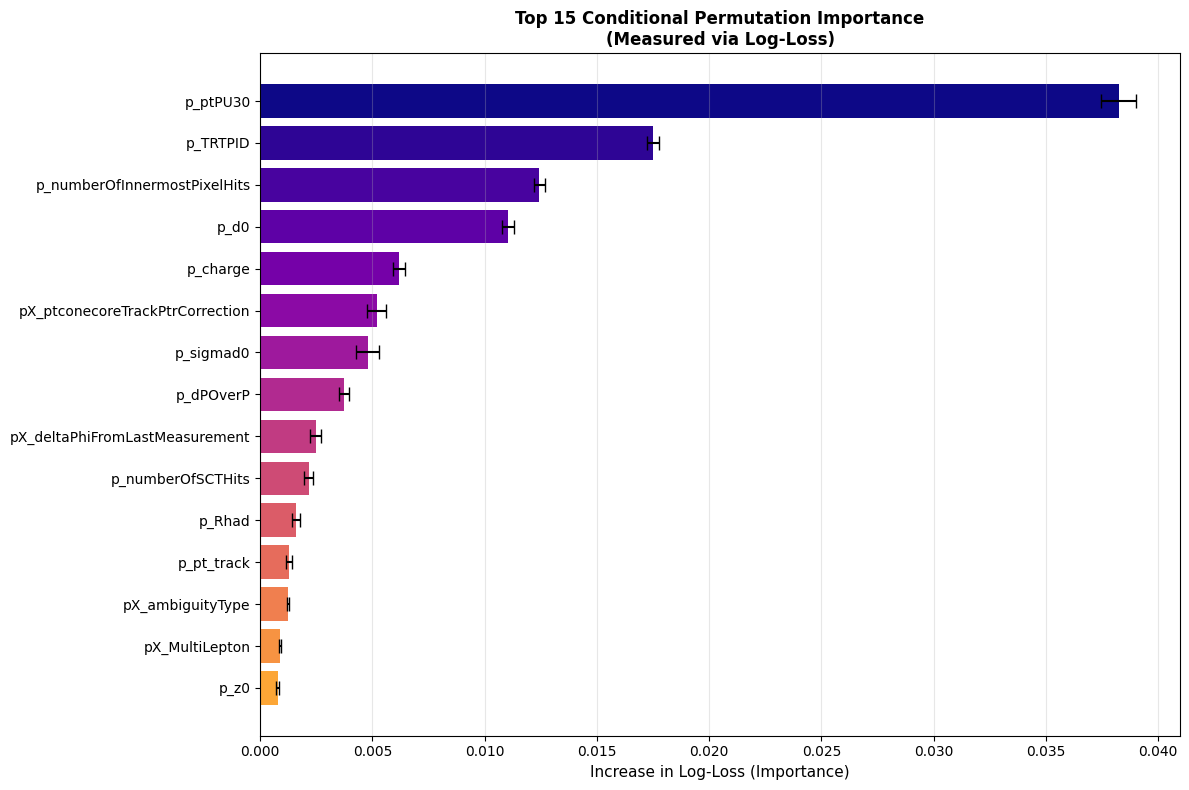

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss  # Added for more granular importance
from xgboost import XGBClassifier, XGBRegressor
from tqdm import tqdm

# --- Data Loading and Initial Prep ---
class_train_data = pd.read_csv('../Data/AppML_InitialProject_train.csv')
target = class_train_data['p_Truth_isElectron']
variables = class_train_data.drop(columns=['p_Truth_isElectron', 'p_Truth_Energy'])

X_train, X_val, y_train, y_val = train_test_split(
    variables, target, test_size=0.2, random_state=42, stratify=target
)

# --- Train Main Model ---
model = XGBClassifier(
    n_estimators=700,
    max_depth=7,
    learning_rate=0.04,
    subsample=0.6,
    colsample_bytree=0.85,
    gamma=2.4,
    min_child_weight=7,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

# --- Updated Conditional Permutation Importance ---
def conditional_permutation_importance(model, X_train, X_val, y_val, features=None, n_repeats=10, rng_seed=42):
    rng = np.random.default_rng(rng_seed)
    
    # Use Log-Loss as the baseline (lower is better)
    probs_val = model.predict_proba(X_val)
    baseline_loss = log_loss(y_val, probs_val)
    
    if features is None:
        features = X_train.columns
        
    records = []
    
    for feature in tqdm(features, desc='Computing CPI (Log-Loss)', unit='feature'):
        other_cols = [c for c in X_train.columns if c != feature]

        # Fit regressor to model feature dependencies
        reg = XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42, n_jobs=-1)
        reg.fit(X_train[other_cols], X_train[feature])

        # Calculate residuals on TRAIN
        preds_train = reg.predict(X_train[other_cols])
        residuals = (X_train[feature] - preds_train).to_numpy()
        
        # Calculate predicted base for VAL
        preds_val_base = reg.predict(X_val[other_cols])
        
        losses = []
        for _ in range(n_repeats):
            # Sample residuals and reconstruct feature
            sampled_resid = rng.choice(residuals, size=len(preds_val_base), replace=True)
            Xc = X_val.copy()
            Xc[feature] = preds_val_base + sampled_resid
            
            # Measure how much the Log-Loss increases (higher increase = more important)
            perm_probs = model.predict_proba(Xc)
            perm_loss = log_loss(y_val, perm_probs)
            losses.append(perm_loss - baseline_loss)
            
        records.append((feature, float(np.mean(losses)), float(np.std(losses))))

    imp_df = pd.DataFrame(records, columns=['feature', 'importance', 'std']).sort_values('importance', ascending=False)
    return imp_df

# Run importance (Note: passed X_train.columns to the 'features' argument)
importance_df = conditional_permutation_importance(
    model, X_train, X_val, y_val, features=X_train.columns, n_repeats=10
)

# --- Visualization ---
top_n = 15
top_features = importance_df.head(top_n)
plt.figure(figsize=(12, 8))
plt.barh(top_features['feature'], top_features['importance'], 
         xerr=top_features['std'], color=plt.cm.plasma(np.linspace(0, 0.8, top_n)), capsize=5)
plt.xlabel('Increase in Log-Loss (Importance)', fontsize=11)
plt.title(f'Top {top_n} Conditional Permutation Importance\n(Measured via Log-Loss)', fontsize=12, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [23]:
# Retrain with top features
top_feature_names = top_features['feature'].tolist()
X_train_top = X_train[top_feature_names]
X_val_top = X_val[top_feature_names]

model_top = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

model_top.fit(X_train_top, y_train)
train_score_top = model_top.score(X_train_top, y_train)
val_score_top = model_top.score(X_val_top, y_val)

print(f'Train accuracy with top features: {train_score_top:.4f}')
print(f'Validation accuracy with top features: {val_score_top:.4f}')

Train accuracy with top features: 0.9797
Validation accuracy with top features: 0.9684


In [28]:
# You may need to install this if you haven't: !pip install scikit-optimize
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical
from xgboost import XGBClassifier

# Define the search space
# Note: Unlike Scipy's uniform(loc, scale), skopt uses (low, high)
search_space = {
    'n_estimators': Integer(2300, 3300),
    'max_depth': Integer(5, 20),
    'learning_rate': Real(0.025, 0.075, prior='log-uniform'), # Log-uniform is better for learning rates
    'subsample': Real(0.4, 1.0),
    'colsample_bytree': Real(0.5, 1.0),
    'gamma': Real(1.5, 4.0),
    'min_child_weight': Integer(2, 20)
}

# Initialize BayesSearchCV
# n_iter=50 in Bayes is often more effective than n_iter=100 in Random Search
bayes_search = BayesSearchCV(
    estimator=XGBClassifier(
        eval_metric='logloss', 
        random_state=42, 
        n_jobs=-1,
        tree_method='hist' # Speeds up training significantly
    ),
    search_spaces=search_space,
    n_iter=50,       # Number of parameter settings sampled
    cv=5,            # 5-fold cross-validation
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# Fit on the reduced feature set (top 15)
# Assuming X_train_top and X_val_top were created from your CPI results
bayes_search.fit(X_train_top, y_train)

print(f'Best CV score: {bayes_search.best_score_:.4f}')
print(f'Best parameters: {bayes_search.best_params_}')

# Final evaluation
best_model = bayes_search.best_estimator_
val_score_tuned = best_model.score(X_val_top, y_val)
print(f'Validation accuracy after Bayesian tuning: {val_score_tuned:.4f}')

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

In [21]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# Hyperparameter tuning for XGBoost on the reduced 15-feature set
param_distributions = {
    'n_estimators': randint(650, 1001),
    'max_depth': randint(5, 10),
    'learning_rate': uniform(0.025, 0.05),
    'subsample': uniform(0.45, 0.18),
    'colsample_bytree': uniform(0.85, 0.15),
    'gamma': uniform(1.5, 2.5),
    'min_child_weight': randint(2, 7)
}

random_search = RandomizedSearchCV(
    estimator=XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1),
    param_distributions=param_distributions,
    n_iter=100,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X_train_top, y_train)

print(f'Best CV score: {random_search.best_score_:.4f}')
print(f'Best parameters: {random_search.best_params_}')

best_model = random_search.best_estimator_
val_score_tuned = best_model.score(X_val_top, y_val)
print(f'Validation accuracy after tuning: {val_score_tuned:.4f}')

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best CV score: 0.9690
Best parameters: {'colsample_bytree': np.float64(0.8595267744385002), 'gamma': np.float64(1.5920546690899784), 'learning_rate': np.float64(0.03169260594003166), 'max_depth': 9, 'min_child_weight': 5, 'n_estimators': 846, 'subsample': np.float64(0.6299491811915034)}
Validation accuracy after tuning: 0.9679


In [ ]:
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score
def objective(trial):
    params = {
      "n_estimators": trial.suggest_int("n_estimators", 200, 1000),
      "max_depth": trial.suggest_int("max_depth", 3, 10),
      "learning_rate": trial.suggest_loguniform("learning_rate", 0.01, 0.2),
      "subsample": trial.suggest_uniform("subsample", 0.4, 1.0),
      "colsample_bytree": trial.suggest_uniform("colsample_bytree", 0.5, 1.0),
      "gamma": trial.suggest_loguniform("gamma", 1e-2, 5.0),
      "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
      "random_state": 42,
      "n_jobs": -1,
    }
    model = XGBClassifier(**params, use_label_encoder=False, eval_metric='logloss')
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train_top, y_train, cv=cv, scoring="neg_log_loss", n_jobs=1)
    return float(scores.mean())

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=150, show_progress_bar=True)
print(study.best_params)

In [6]:
from pathlib import Path

# Load test data and extract top features
X_test = class_test_data[top_feature_names]

# Get probability predictions for class 1 (electron)
test_predictions = best_model.predict_proba(X_test)[:, 1]

# Define output paths and filenames
solution_name = "XGBoost"
name = "BenjaminSiddique"
output_dir = Path('../Classification/Output')
output_dir.mkdir(exist_ok=True)

# Export predictions
predictions_filename = f"Classification_{name}_{solution_name}.csv"
predictions_filepath = output_dir / predictions_filename
with open(predictions_filepath, 'w') as f:
    for idx, pred in enumerate(test_predictions):
        f.write(f"{idx},{pred:.6f}\n")

#Export chosen features
varlist_filename = f"Classification_{name}_{solution_name}_VariableList.csv"
varlist_filepath = output_dir / varlist_filename
with open(varlist_filepath, 'w') as f:
    for var in top_feature_names:
        f.write(f"{var}\n")

In [8]:
#Calculate crossentrpy loss on validation set
from sklearn.metrics import log_loss
val_probs = best_model.predict_proba(X_val_top)
val_log_loss = log_loss(y_val, val_probs)
print(f'Validation log loss after tuning: {val_log_loss:.4f}')


Validation log loss after tuning: 0.0761


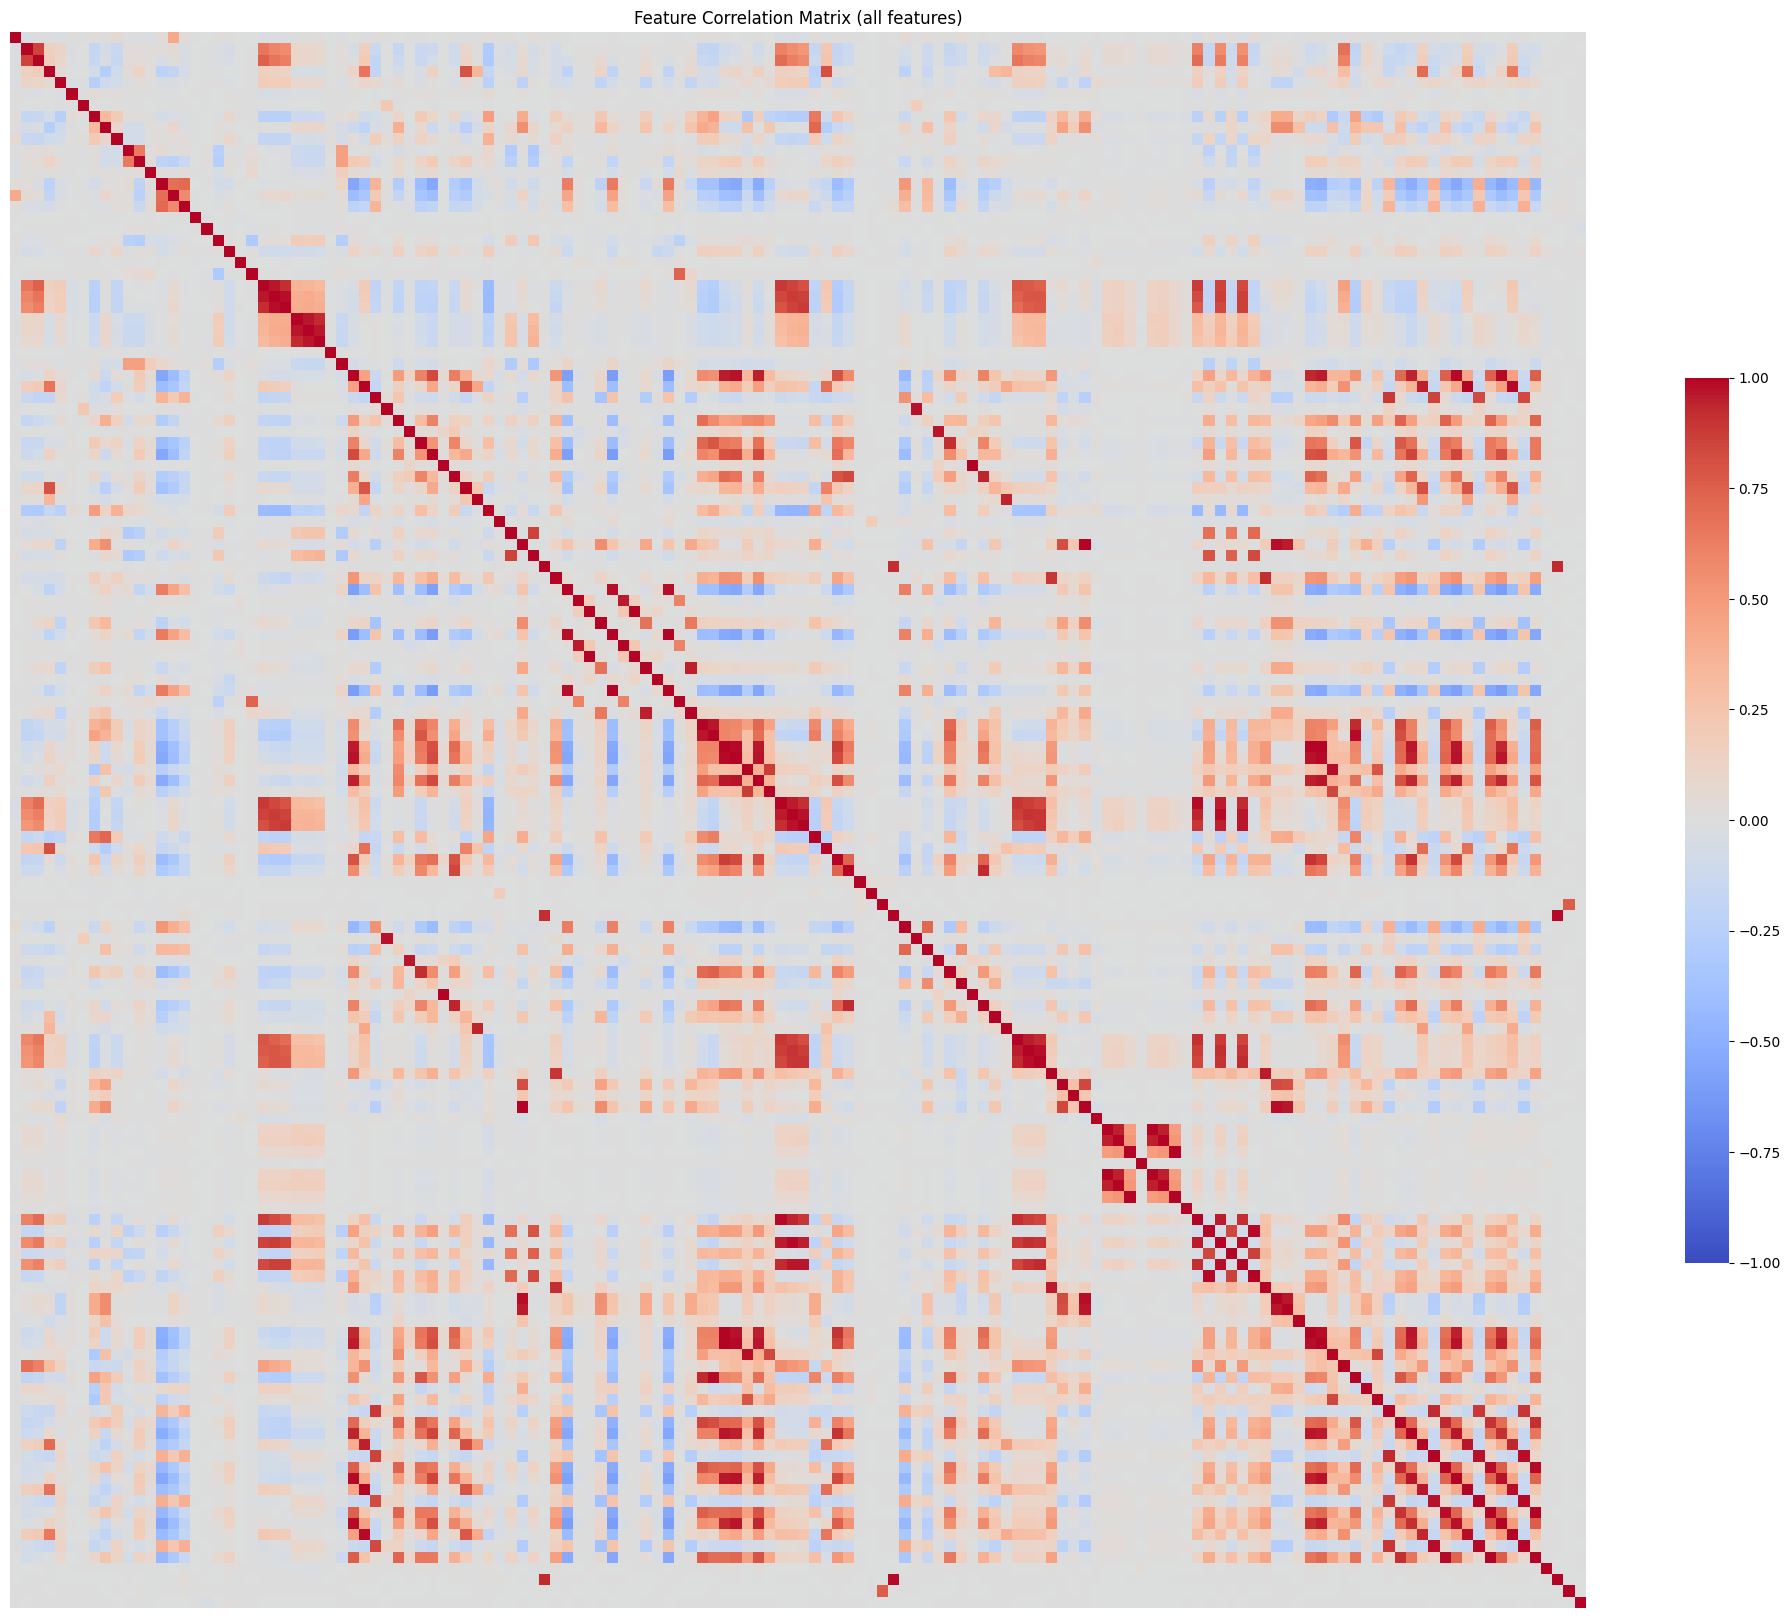

In [11]:
# Plot correlation matrix for all features
import seaborn as sns
# Prepare feature matrix (exclude target/energy if present)
features = class_train_data.drop(columns=['p_Truth_isElectron', 'p_Truth_Energy'])
corr = features.corr()
plt.figure(figsize=(20, 18))
sns.heatmap(corr, cmap='coolwarm', center=0, vmin=-1, vmax=1,
            xticklabels=False, yticklabels=False, square=True, cbar_kws={'shrink':0.5})
plt.title('Feature Correlation Matrix (all features)')
plt.tight_layout()
plt.show()

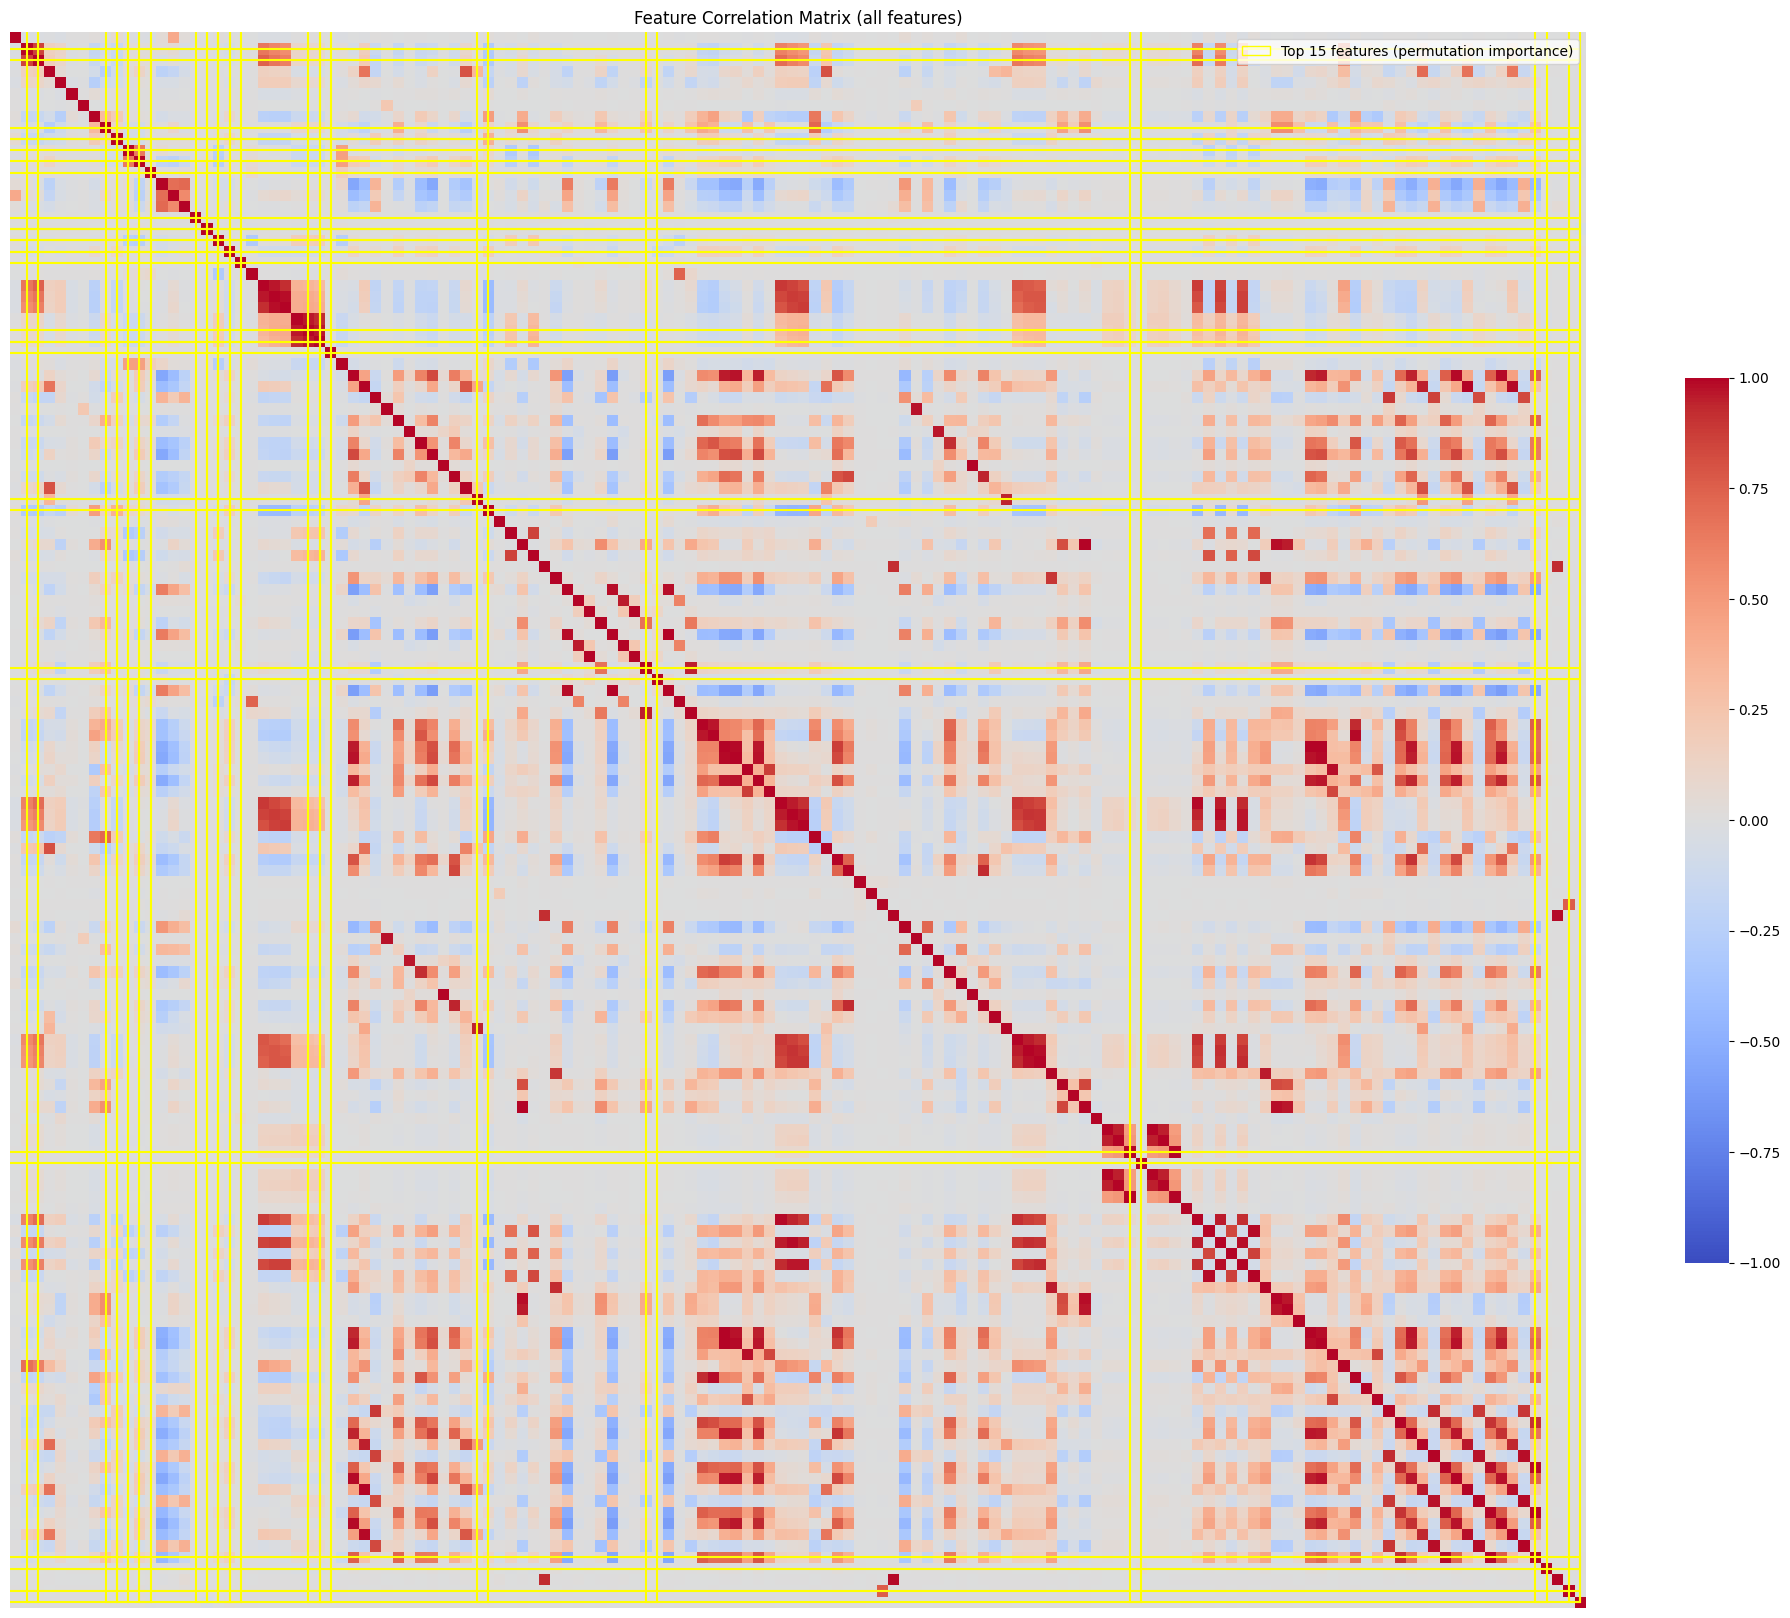

In [13]:
# Plot correlation matrix for all features and outline top-permutation features
import seaborn as sns
import matplotlib.patches as patches
# Prepare feature matrix (exclude target/energy if present)
features = class_train_data.drop(columns=['p_Truth_isElectron', 'p_Truth_Energy'])
corr = features.corr()
order = list(corr.columns)
n = len(order)
fig, ax = plt.subplots(figsize=(20, 18))
sns.heatmap(corr, cmap='coolwarm', center=0, vmin=-1, vmax=1,
            xticklabels=False, yticklabels=False, square=True, cbar_kws={'shrink':0.5}, ax=ax)
# Identify top features (ensure they exist in the training features)
top = [f for f in top_feature_names if f in order]
# Draw outlines for each top feature: full row and full column
for f in top:
    idx = order.index(f)
    # Outline the row
    row_rect = patches.Rectangle((-0.5, idx-0.5), n, 1, linewidth=1.5, edgecolor='yellow', facecolor='none')
    ax.add_patch(row_rect)
    # Outline the column
    col_rect = patches.Rectangle((idx-0.5, -0.5), 1, n, linewidth=1.5, edgecolor='yellow', facecolor='none')
    ax.add_patch(col_rect)
# Add a legend patch explaining the outline
legend_patch = patches.Patch(edgecolor='yellow', facecolor='none', label=f'Top {len(top)} features (permutation importance)')
ax.legend(handles=[legend_patch], loc='upper right')
plt.title('Feature Correlation Matrix (all features)')
plt.tight_layout()
plt.show()
